## IMPORT LIBRARY

In [1]:

import pandas as pd
import numpy as np

## IMPORT DATA

In [2]:
df1 = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/aartirahul/ipl/athlete_events.csv")
df2 = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/aartirahul/ipl/noc_regions.csv")

In [3]:
df1.sample(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
58232,29798,Brennon James Dowrick,M,20.0,170.0,70.0,Australia,AUS,1992 Summer,1992,Summer,Barcelona,Gymnastics,Gymnastics Men's Parallel Bars,NaN
168754,84820,Lyudmil Naydenov,M,25.0,NaN,NaN,Bulgaria,BUL,1996 Summer,1996,Summer,Atlanta,Volleyball,Volleyball Men's Volleyball,NaN
134116,67528,Catriona Ann Le May Doan,F,21.0,170.0,70.0,Canada,CAN,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
78817,40009,Khaled Al-Ghezzawi,M,17.0,170.0,69.0,Libya,LBA,2004 Summer,2004,Summer,Athina,Swimming,Swimming Men's 50 metres Freestyle,NaN
110122,55686,K. C. Jones,M,24.0,185.0,91.0,United States,USA,1956 Summer,1956,Summer,Melbourne,Basketball,Basketball Men's Basketball,Gold


In [4]:
df1.shape

(271116, 15)

In [5]:
df1 = df1[df1['Season'] == 'Summer']
df1.sample(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
71656,36477,Fakhredin Fouad Al-Dien Gor,M,28.0,192.0,73.0,Jordan,JOR,1996 Summer,1996,Summer,Atlanta,Athletics,Athletics Men's High Jump,NaN
151606,76084,Aldo Masciotta,M,26.0,NaN,NaN,Italy,ITA,1936 Summer,1936,Summer,Berlin,Fencing,"Fencing Men's Sabre, Team",Silver
149637,75051,Jos Marn Sospedra,M,34.0,164.0,60.0,Spain,ESP,1984 Summer,1984,Summer,Los Angeles,Athletics,Athletics Men's 20 kilometres Walk,NaN
35164,18112,Leonida Caraiosifoglu,M,23.0,186.0,75.0,Romania,ROU,1968 Summer,1968,Summer,Mexico City,Athletics,Athletics Men's 20 kilometres Walk,NaN
80019,40612,Jean-Pierre Giubbini,M,33.0,176.0,77.0,Switzerland,SUI,1960 Summer,1960,Summer,Roma,Hockey,Hockey Men's Hockey,NaN


In [6]:
df=df1.merge(df2,on='NOC',how= 'left')
df.sample(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
118202,72291,"Peder Eugen Lunde, Sr.",M,34.0,NaN,NaN,Encore,NOR,1952 Summer,1952,Summer,Helsinki,Sailing,Sailing Mixed 5.5 metres,Silver,Norway,NaN
204225,124499,Jan van der Wiel,M,27.0,NaN,NaN,Netherlands,NED,1920 Summer,1920,Summer,Antwerpen,Fencing,"Fencing Men's Foil, Team",NaN,Netherlands,NaN
211409,128942,"Hubert ""Hugh"" Watlington",M,30.0,172.0,67.0,Bermuda,BER,1984 Summer,1984,Summer,Los Angeles,Sailing,Sailing Men's Windsurfer,NaN,Bermuda,NaN
37730,23200,Nadia Cortassa (-Gabba),F,26.0,173.0,56.0,Italy,ITA,2004 Summer,2004,Summer,Athina,Triathlon,Triathlon Women's Olympic Distance,NaN,Italy,NaN
52130,31857,Johan Elof Ekman,M,57.0,NaN,NaN,Sweden,SWE,1912 Summer,1912,Summer,Stockholm,Shooting,"Shooting Men's Running Target, Single Shot",NaN,Sweden,NaN


In [7]:
df.shape

(222552, 17)

In [8]:
df['region'].unique().shape

(206,)

In [9]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9189
Height     51857
Weight     53854
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     188464
region       370
notes     218151
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1385)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = pd.concat([df,pd.get_dummies(df['Medal'],dtype=int)],axis=1)

In [14]:
df.shape

(221167, 20)

In [15]:
year = df['Year'].unique()
year

array([1992, 2012, 1920, 1900, 1932, 1952, 2000, 1996, 1912, 1924, 1948,
       2008, 2016, 2004, 1984, 1968, 1972, 1988, 1936, 1956, 1960, 1928,
       1976, 1980, 1964, 1906, 1904, 1908, 1896])

# COUNTRYWISE MEDAL 

In [16]:
df.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

,region,Gold,Silver,Bronze
0,USA,2472,1333,1197
1,Russia,1220,974,994
2,Germany,1075,987,1064
3,UK,635,729,620
4,Italy,518,474,454
...,...,...,...,...
200,Lesotho,0,0,0
201,Albania,0,0,0
202,Libya,0,0,0
203,Liechtenstein,0,0,0


In [17]:
medal_tally= df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'])
medal_tally

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222528,135553,Galina Ivanovna Zybina (-Fyodorova),F,25.0,168.0,80.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Athletics,Athletics Women's Shot Put,Silver,Russia,NaN,0,0,1
222530,135553,Galina Ivanovna Zybina (-Fyodorova),F,33.0,168.0,80.0,Soviet Union,URS,1964 Summer,1964,Summer,Tokyo,Athletics,Athletics Women's Shot Put,Bronze,Russia,NaN,1,0,0
222536,135556,Bogusaw Stanisaw Zychowicz,M,19.0,189.0,80.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 100 metres Butterfly,NaN,Poland,NaN,0,0,0
222537,135556,Bogusaw Stanisaw Zychowicz,M,19.0,189.0,80.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 200 metres Butterfly,NaN,Poland,NaN,0,0,0


In [18]:
medal_tally.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

,region,Gold,Silver,Bronze
0,USA,1035,802,708
1,Russia,592,498,487
2,Germany,444,457,491
3,UK,278,317,300
4,France,234,256,287
...,...,...,...,...
200,Lesotho,0,0,0
201,Albania,0,0,0
202,Libya,0,0,0
203,Liechtenstein,0,0,0


# TOTAL MEDAL ACCORDING COUTRY

In [80]:
medal_tally[medal_tally['region']== 'India'][['Gold','Silver','Bronze']].sum()

Gold       9
Silver     7
Bronze    12
dtype: int64

In [91]:
years =df['Year'].unique().tolist()
years

[1992,
 2012,
 1920,
 1900,
 1932,
 1952,
 2000,
 1996,
 1912,
 1924,
 1948,
 2008,
 2016,
 2004,
 1984,
 1968,
 1972,
 1988,
 1936,
 1956,
 1960,
 1928,
 1976,
 1980,
 1964,
 1906,
 1904,
 1908,
 1896]

In [21]:
years.sort()

In [22]:
years.insert(0, 'Overall')


In [90]:
years

['Overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [24]:
country =df['region'].unique().tolist()

In [25]:
country =np.unique(df['region'].dropna().values).tolist()

In [26]:
country.sort()

In [89]:
country

['Overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Gui

In [28]:
country.insert(0,'Overall')

In [93]:
country

['Overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Gui

In [30]:
def fetch_medal_tally(year,country):
    if year =='Overall' and country =='Overall':
        temp_df = medal_tally
    if year =='Overall' and country !='Overall':
        temp_df = medal_tally[medal_tally['region']==country]
    if year !='Overall' and country =='Overall':
        temp_df = medal_tally[medal_tally['Year'] ==int(year)]
    if year !='Overall' and country !='Overall':
        temp_df = medal_tally[(medal_tally['Year']==int(year)) & (medal_tally['region']==country)]

    x= temp_df.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()
    x['total'] = x['Gold']+ x['Silver']+ x['Bronze']
    print(x)
    

# TOTAL MEDAL

In [31]:
fetch_medal_tally(year=2000,country='China')

  region  Gold  Silver  Bronze  total
0  China    28      16      14     58


In [32]:
medal_tally[(medal_tally['Year'] == int(2000)) & (medal_tally['region']=='China')]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
921,602,Abudoureheman,M,22.0,182.0,75.0,China,CHN,2000 Summer,2000,Summer,Sydney,Boxing,Boxing Men's Middleweight,NaN,China,NaN,0,0,0
5670,3611,An Zhongxin,F,27.0,170.0,65.0,China,CHN,2000 Summer,2000,Summer,Sydney,Softball,Softball Women's Softball,NaN,China,NaN,0,0,0
10733,6851,Bai Jie,F,28.0,163.0,53.0,China,CHN,2000 Summer,2000,Summer,Sydney,Football,Football Women's Football,NaN,China,NaN,0,0,0
27896,17292,Cai Xuemei,F,26.0,166.0,50.0,China,CHN,2000 Summer,2000,Summer,Sydney,Hockey,Hockey Women's Hockey,NaN,China,NaN,0,0,0
27897,17294,Cai Yalin,M,23.0,174.0,60.0,China,CHN,2000 Summer,2000,Summer,Sydney,Shooting,"Shooting Men's Air Rifle, 10 metres",Gold,China,NaN,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221338,134818,Zhou Xiaojing,F,23.0,167.0,50.0,China,CHN,2000 Summer,2000,Summer,Sydney,Rhythmic Gymnastics,Rhythmic Gymnastics Women's Individual,NaN,China,NaN,0,0,0
221356,134830,Zhou Yuanguo,M,22.0,174.0,68.0,China,CHN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Men's Windsurfer,NaN,China,NaN,0,0,0
221369,134839,Zhu Feng,M,17.0,191.0,83.0,China,CHN,2000 Summer,2000,Summer,Sydney,Taekwondo,Taekwondo Men's Heavyweight,NaN,China,NaN,0,0,0
221411,134863,Zhu Yi,M,22.0,177.0,85.0,China,CHN,2000 Summer,2000,Summer,Sydney,Swimming,Swimming Men's 100 metres Breaststroke,NaN,China,NaN,0,0,0


In [33]:
df['Year'].unique().shape[0]

29

In [34]:
df.head(3)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0


#  ADHOC QUESTION

In [35]:
df['City'].unique()

array(['Barcelona', 'London', 'Antwerpen', 'Paris', 'Los Angeles',
       'Helsinki', 'Sydney', 'Atlanta', 'Stockholm', 'Beijing',
       'Rio de Janeiro', 'Athina', 'Mexico City', 'Munich', 'Seoul',
       'Berlin', 'Melbourne', 'Roma', 'Amsterdam', 'Montreal', 'Moskva',
       'Tokyo', 'St. Louis'], dtype=object)

In [36]:
df['City'].unique().shape[0]

23

In [37]:
df['Sport'].unique()

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Equestrianism',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Modern Pentathlon', 'Golf', 'Softball', 'Archery',
       'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
       'Rhythmic Gymnastics', 'Rugby Sevens', 'Trampolining',
       'Beach Volleyball', 'Triathlon', 'Rugby', 'Lacrosse', 'Polo',
       'Cricket', 'Ice Hockey', 'Racquets', 'Motorboating', 'Croquet',
       'Figure Skating', 'Jeu De Paume', 'Roque', 'Basque Pelota',
       'Alpinism', 'Aeronautics'], dtype=object)

In [38]:
df['Sport'].unique().shape[0]

52

In [39]:
df['Event'].unique().shape[0]

651

In [40]:
df['Name'].unique().shape[0]

116122

In [41]:
df['region'].unique().shape[0]

206

In [42]:
df.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0


In [43]:
nations_over_time =df.drop_duplicates(['Year','region'])['Year'].value_counts().reset_index().sort_values('Year')

# COUNTRY PER YEAR

In [94]:
nations_over_time

,Year,no of countries
28,1896,12
22,1900,31
27,1904,14
26,1906,20
25,1908,22
24,1912,29
23,1920,29
21,1924,45
20,1928,46
19,1932,47


In [45]:
nations_over_time.columns

Index(['Year', 'count'], dtype='object')

In [46]:
import plotly.express as px

In [47]:
nations_over_time.rename(columns={'index':'Edition','count':'no of countries'},inplace=True)

# NO. OF COUNTRIES PER YEAR

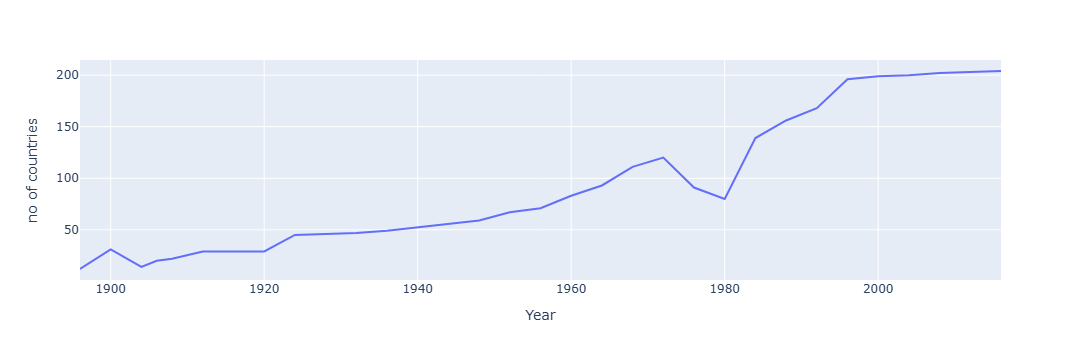

In [48]:
fig= px.line(nations_over_time,x='Year',y='no of countries')
fig.show()

In [49]:
events_over_time =df.drop_duplicates(['Year','Event'])['Year'].value_counts().reset_index().sort_values('Year')
events_over_time

,Year,count
28,1896,43
26,1900,90
25,1904,95
27,1906,74
23,1908,109
24,1912,107
14,1920,158
20,1924,131
22,1928,122
21,1932,131


# EVENT PER COUNT

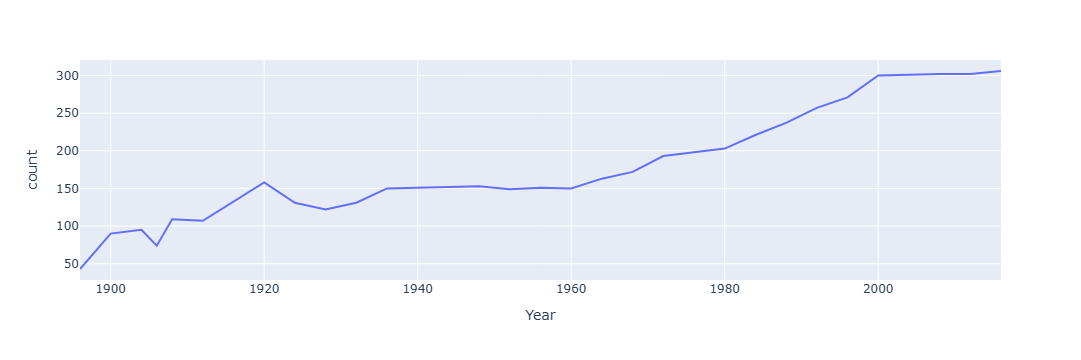

In [50]:
fig= px.line(events_over_time,x='Year',y='count')
fig.show()

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
x=df.drop_duplicates(['Year','Sport','Event'])




# HEATMAP NO. OF EVENTS IN SPORT PER YEAR

<Axes: xlabel='Year', ylabel='Sport'>

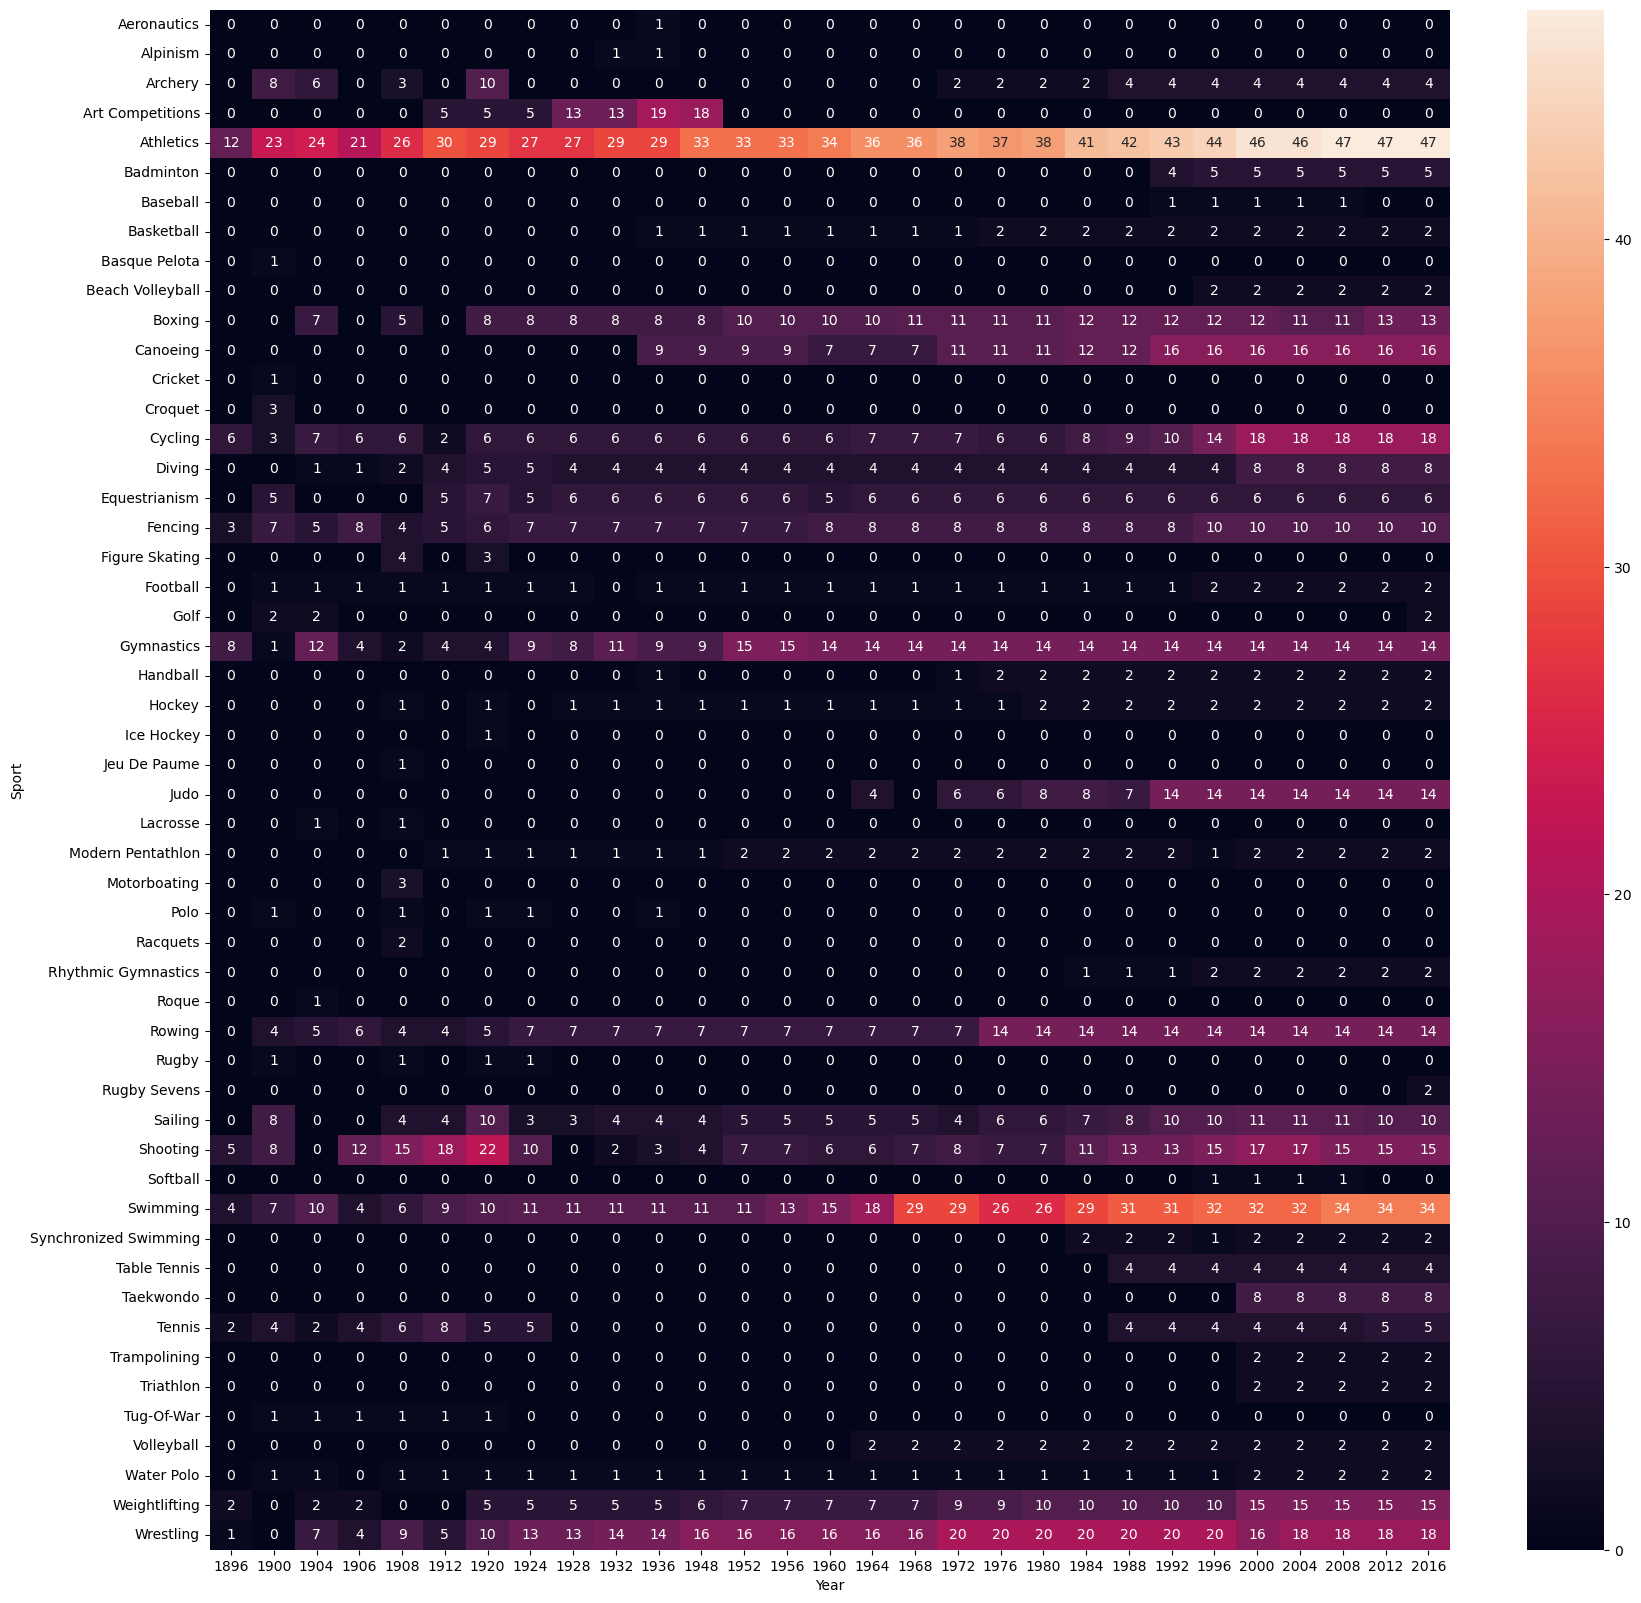

In [95]:
plt.figure(figsize=(20,20))
sns.heatmap(x.pivot_table(index='Sport',columns='Year',values='Event',aggfunc='count').fillna(0).astype('int'),annot=True)

In [54]:
def most_successful(df,sport):
    temp_df = df.dropna(subset=['Medal'])
    if sport!= 'Overall':
        temp_df= temp_df[temp_df['Sport'] == sport]

    x = temp_df['Name'].value_counts().reset_index().head(5).merge(df,left_on='Name',right_on='Name',how='left')[['Name','Sport','region']].drop_duplicates('Names')
    x.rename(columns={'index':'Name','Name_x':'Medals'},inplace=True)
    return x

In [55]:
most_successful(df,'Overall')

KeyError: Index(['Names'], dtype='object')

In [56]:
temp_df = df.dropna(subset=['Medal'])
temp_df
temp_dftemp=temp_df['Name'].value_counts().reset_index()
print(temp_df.columns)

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region', 'notes',
       'Bronze', 'Gold', 'Silver'],
      dtype='object')


In [57]:
temp_df = df.dropna(subset=['Medal'])
temp_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
12,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland,NaN,1,0,0
13,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland,NaN,1,0,0
15,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland,NaN,1,0,0
16,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold,Finland,NaN,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222528,135553,Galina Ivanovna Zybina (-Fyodorova),F,25.0,168.0,80.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Athletics,Athletics Women's Shot Put,Silver,Russia,NaN,0,0,1
222530,135553,Galina Ivanovna Zybina (-Fyodorova),F,33.0,168.0,80.0,Soviet Union,URS,1964 Summer,1964,Summer,Tokyo,Athletics,Athletics Women's Shot Put,Bronze,Russia,NaN,1,0,0
222532,135554,Bogusaw Zych,M,28.0,182.0,82.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Fencing,"Fencing Men's Foil, Team",Bronze,Poland,NaN,1,0,0
222544,135563,Olesya Nikolayevna Zykina,F,19.0,171.0,64.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Women's 4 x 400 metres Relay,Bronze,Russia,NaN,1,0,0


In [58]:
temp_df = df.dropna(subset=['Medal'])
temp_df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'],inplace= True)


C:\Users\Dell\AppData\Local\Temp\ipykernel_3860\1369370254.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [59]:
new_df= temp_df[temp_df['region'] =='China']
final_df = new_df.groupby('Year').count()['Medal'].reset_index()

# COUNTRYWISE MEDAL PER YEAR

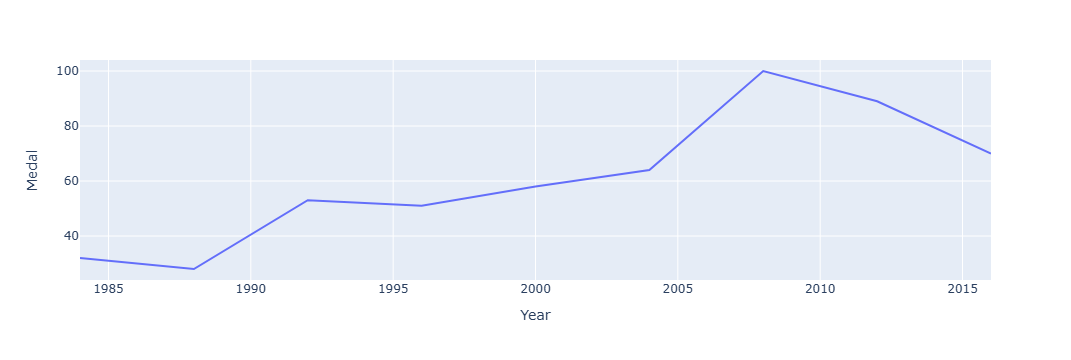

In [60]:
fig = px.line(final_df,x='Year',y='Medal')
fig.show()

# HEATMAP SPORTS PER YEAR

<Axes: xlabel='Year', ylabel='Sport'>

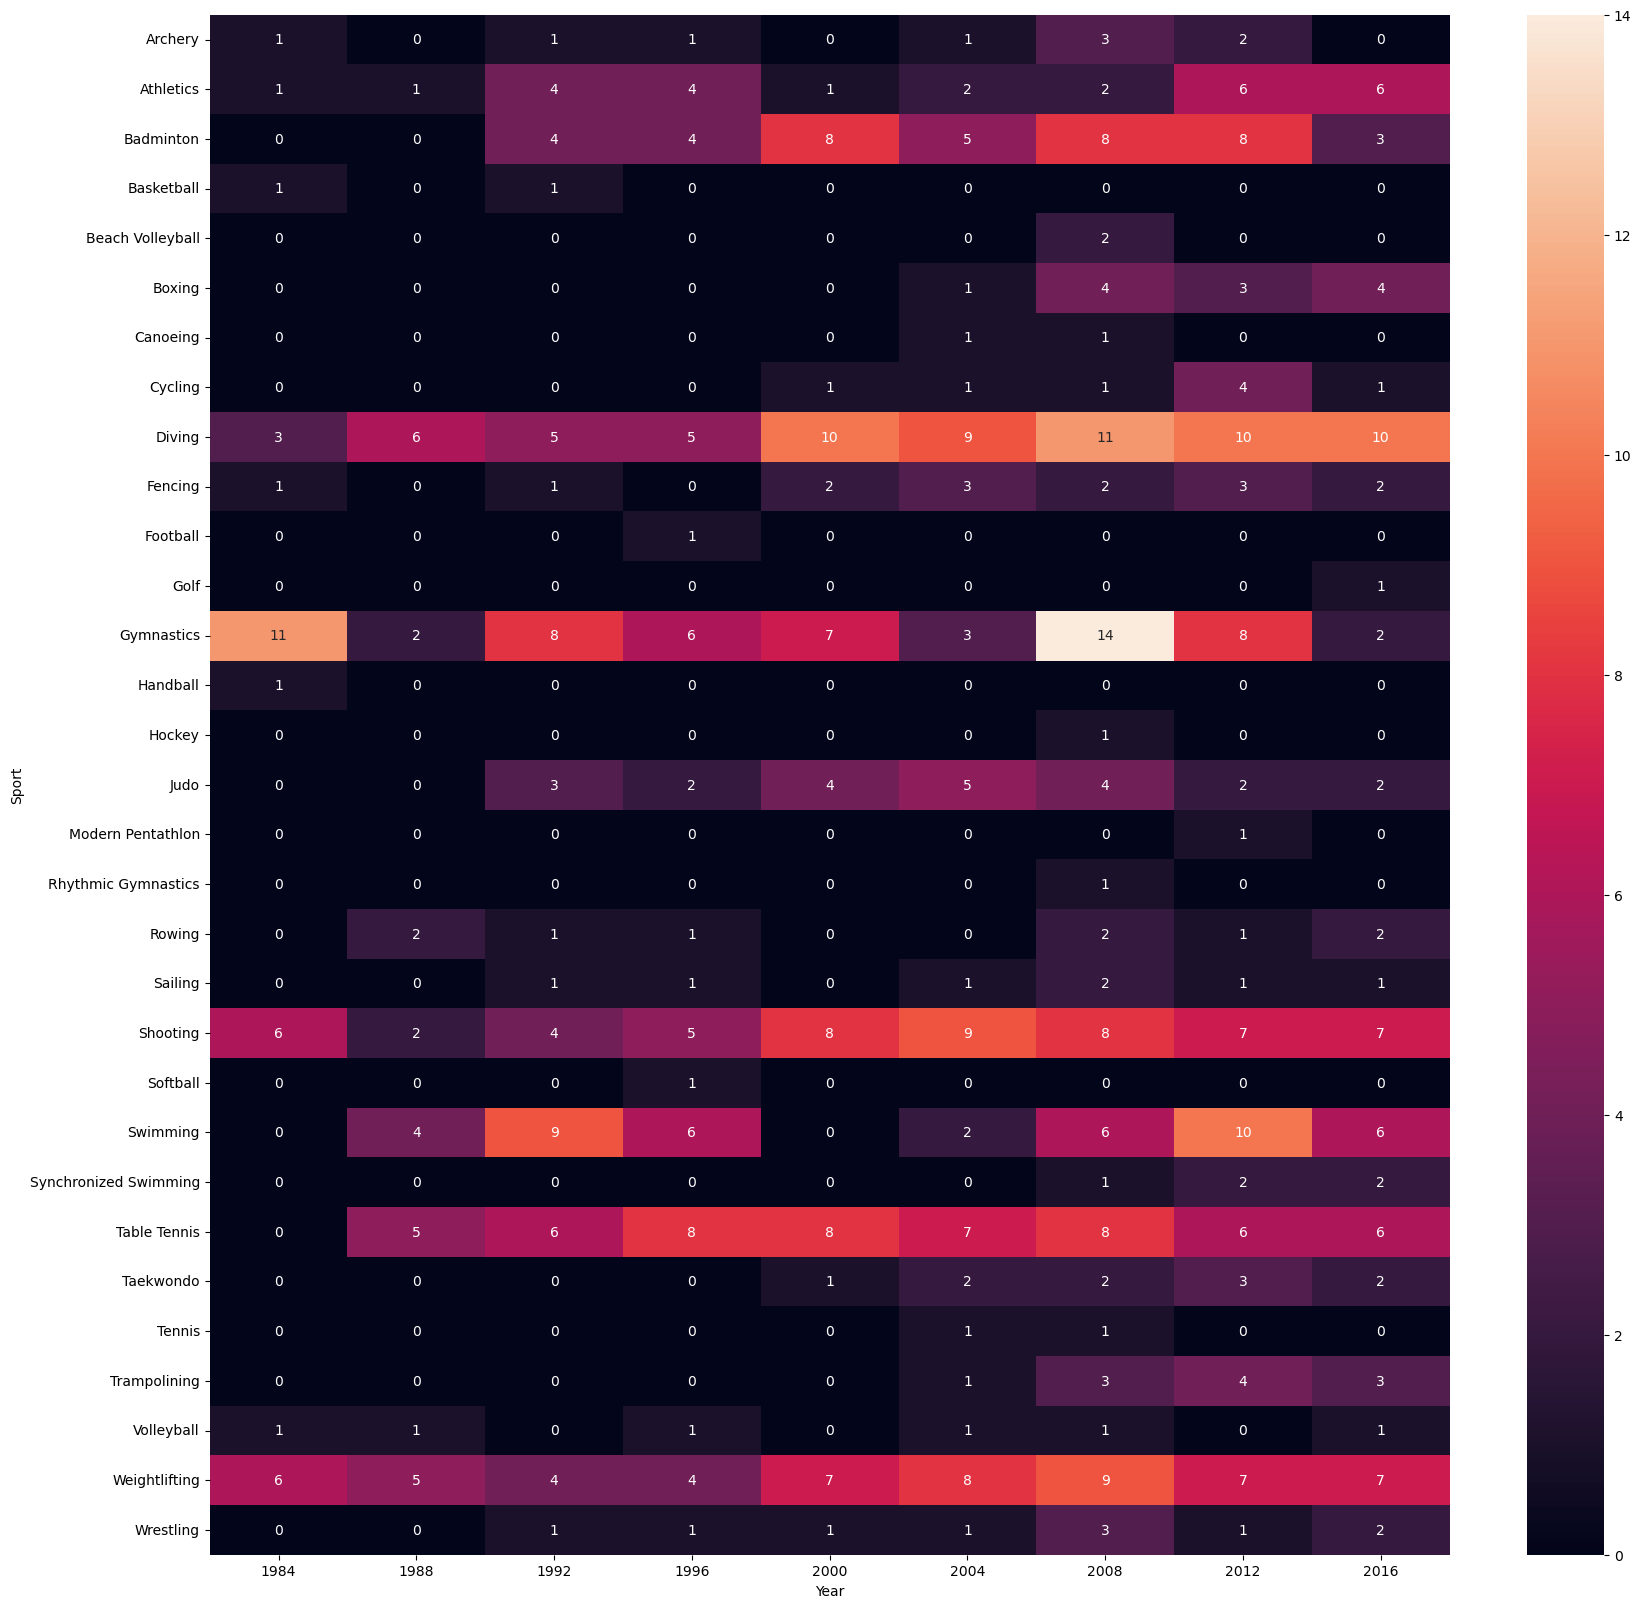

In [96]:
new_df = temp_df[temp_df['region'] == 'China']
plt.figure(figsize=(20,20))
sns.heatmap(new_df.pivot_table(index='Sport',columns= 'Year',values='Medal',aggfunc='count').fillna(0),annot=True)

In [62]:
def most_successful(df,country):
    temp_df = df.dropna(subset=['Medal'])
    temp_df= temp_df[temp_df['Sport'] == country]

    x = temp_df['Name'].value_counts().reset_index().head(5).merge(df,left_on='Name',right_on='Name',how='left')[['Name','name_x','Sport']].drop_duplicates('Names')
    x.rename(columns={'index':'Name','Name_x':'Medals'},inplace=True)
    return x

In [63]:
most_successful(df,'India')

KeyError: "['name_x'] not in index"

In [103]:
athlete_df = df.drop_duplicates(subset=['Name','region'])
men = athlete_df[athlete_df['Sex'] == 'M'].groupby('Year').count()['Name'].reset_index()
women = athlete_df[athlete_df['Sex'] == 'F'].groupby('Year').count()['Name'].reset_index()

In [104]:
women

,Year,Name
0,1900,23
1,1904,6
2,1906,6
3,1908,44
4,1912,53
5,1920,73
6,1924,132
7,1928,285
8,1932,162
9,1936,316


In [105]:
final = men.merge(women,on='Year',how='left')
final.rename(columns={'Name_x':'Male','Name_y': 'Female'},inplace= True)

In [106]:
men,women,final

(    Year  Name
 0   1896   174
 1   1900  1181
 2   1904   629
 3   1906   759
 4   1908  1772
 5   1912  1978
 6   1920  2280
 7   1924  2535
 8   1928  2342
 9   1932  1382
 10  1936  3539
 11  1948  3629
 12  1952  3468
 13  1956  2193
 14  1960  3755
 15  1964  3290
 16  1968  3555
 17  1972  4552
 18  1976  3320
 19  1980  3151
 20  1984  4299
 21  1988  4704
 22  1992  4769
 23  1996  4811
 24  2000  4294
 25  2004  3931
 26  2008  3990
 27  2012  3679
 28  2016  4022,
     Year  Name
 0   1900    23
 1   1904     6
 2   1906     6
 3   1908    44
 4   1912    53
 5   1920    73
 6   1924   132
 7   1928   285
 8   1932   162
 9   1936   316
 10  1948   420
 11  1952   409
 12  1956   288
 13  1960   473
 14  1964   507
 15  1968   599
 16  1972   818
 17  1976  1028
 18  1980   875
 19  1984  1368
 20  1988  1734
 21  1992  2080
 22  1996  2518
 23  2000  2790
 24  2004  2820
 25  2008  2947
 26  2012  2919
 27  2016  3209,
     Year  Male  Female
 0   1896   174     NaN
 1   1

In [101]:
final.fillna(0,inplace=True)

# PARTCIPATION OF MEN AND WOMEN PER YEAR

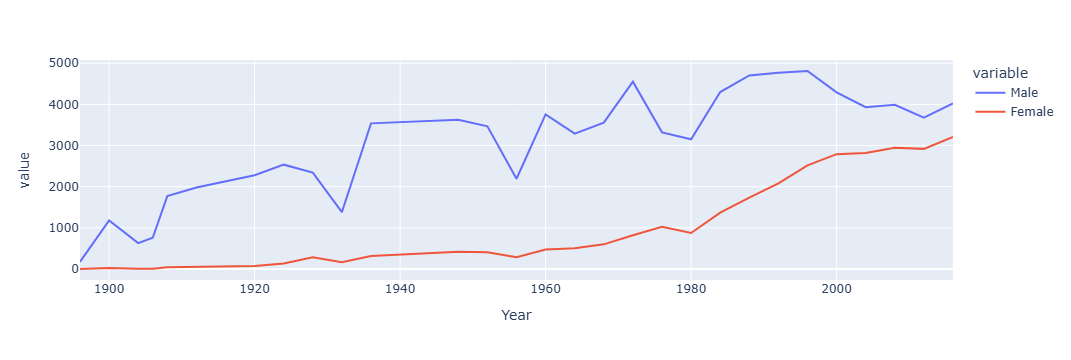

In [102]:
fig = px.line(final,x='Year',y=['Male','Female'])
fig.show()